In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, Point
import math
from skimage.measure import block_reduce
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, f1_score

from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from rasterio.windows import Window

In [4]:
import lightgbm as lgbm

In [5]:
from utils.site import Site
from utils.sentinel_scene import SentinelScene
from utils.tree import Tree
from utils.constants import SILVER_FOLDERPATH, ETHZ_COCOA_MAP_FILEPATH, ETHZ_COCOA_MAP_UINT8_FILEPATH, ETHZ_COCOA_MASK_FILEPATH, SENTINEL_GH_SCENES_FILEPATH

In [6]:
# Load
scenes = joblib.load(SENTINEL_GH_SCENES_FILEPATH)
scenes[0].id

'S2A_30NWL_20200115_1_L2A'

In [7]:
ss = SentinelScene.from_scene_id(scenes[1].id)

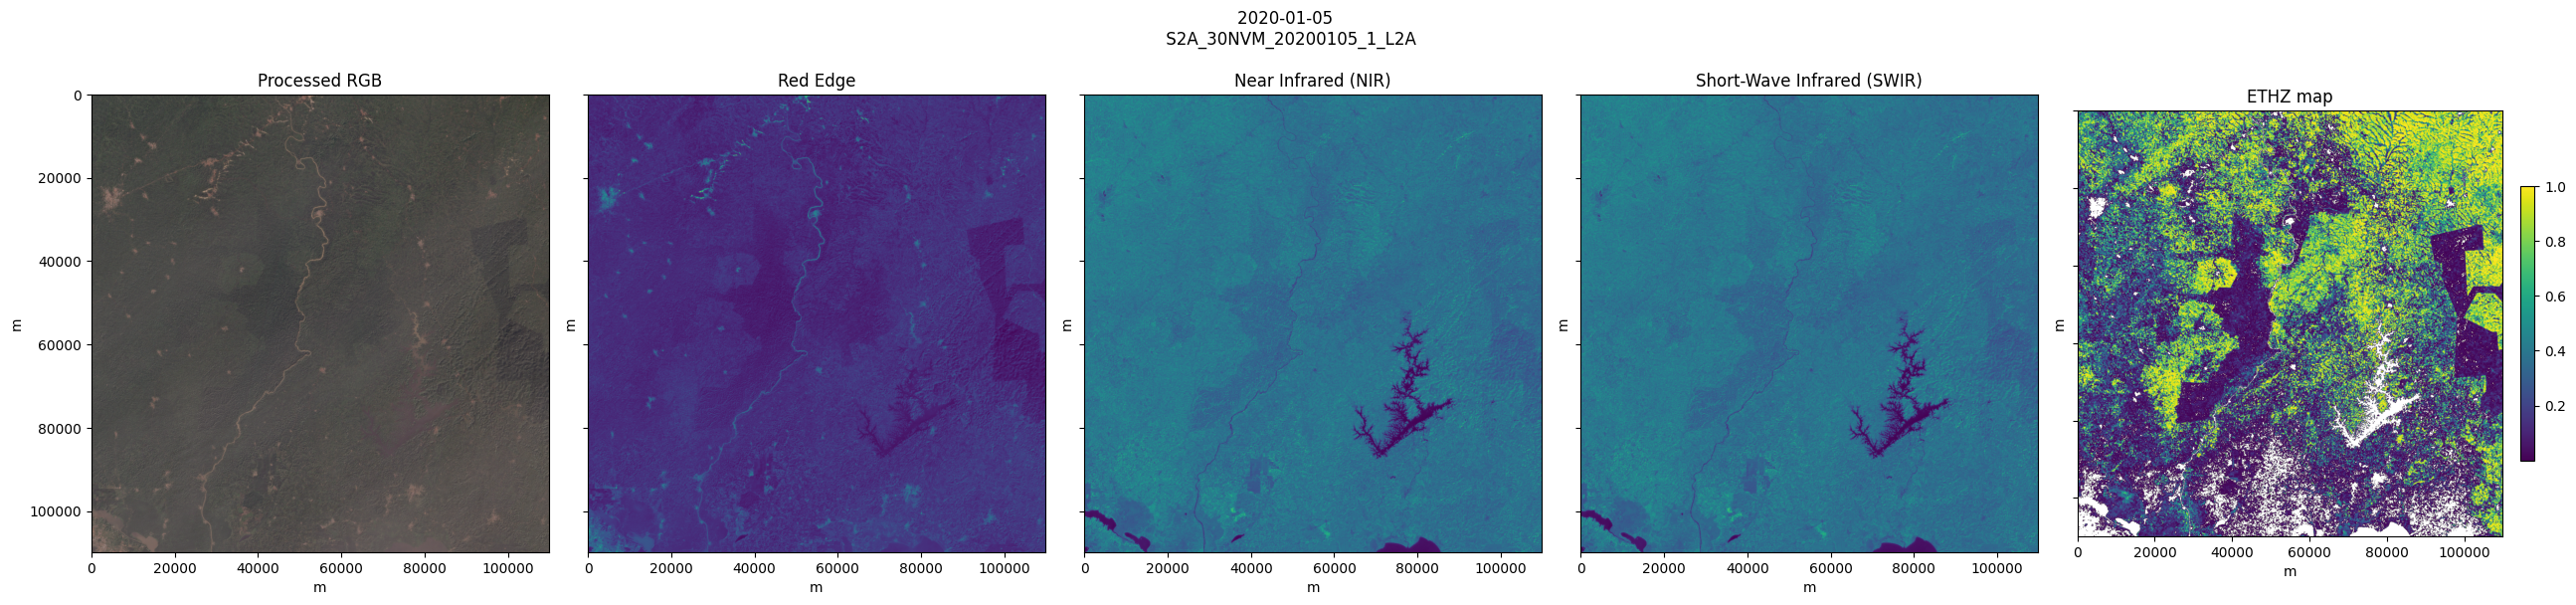

In [36]:
ss.plot(plot_scale=2)

In [9]:
ss.bounds

BoundingBox(left=-3.9044791458419223, bottom=5.33908695468687, right=-2.9117544337127175, top=6.333042162293402)

In [10]:
X, y = ss.compute_Xy()

In [15]:
ss.processed_rgb.shape

(10980, 10980, 3)

In [8]:
# Val
ss = SentinelScene.from_scene_id(scenes[1].id)
X_val, y_val = ss.compute_Xy()
X_val.head(1)

,tci,ndvi,nir,swir
0,718.354187,0.528642,2802.0,1273.0


In [9]:
reg = lgbm.LGBMRegressor(max_depth=10, objective='cross_entropy')

In [10]:
reg.fit(X_train, y_train)

[LightGBM] [Info] [cross_entropy:Init]: (objective) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: (metric) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: sum-of-weights = 70598569.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.308822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 70598569, number of used features: 4
[LightGBM] [Info] [cross_entropy:BoostFromScore]: pavg = 0.563261 -> initscore = 0.254407
[LightGBM] [Info] Start training from score 0.254407


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'cross_entropy'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
yhat_train = reg.predict(X_train)
print(f"Train MAE: {mean_absolute_error(y_train, yhat_train):.4f}")

Train MAE: 0.2049


In [14]:
yhat_val = reg.predict(X_val)
print(f"Val MAE: {mean_absolute_error(y_val, yhat_val):.4f}")

Val MAE: 0.2108


In [19]:
THRESH = 0.65

In [20]:
f1_score(y_train > THRESH, yhat_train > THRESH)

0.7559634623597662

In [21]:
f1_score(y_val > THRESH, yhat_val > THRESH)

0.6936919806346804